<a href="https://www.kaggle.com/code/lalit7881/ai-and-the-future-of-work?scriptVersionId=301855446" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/future-of-work-in-the-age-of-ai-20202026/ai_job_replacement_2020_2026_v2.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/algozee/future-of-work-in-the-age-of-ai-20202026/ai_job_replacement_2020_2026_v2.csv")

In [3]:
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [4]:
df.tail()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
14995,14995,HR Manager,Finance,Canada,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,Medium,22.555,2.83,18.787,3.497570
14996,14996,Software Engineer,Energy,India,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,Low,25.305,3.53,17.810,3.573472
14997,14997,Truck Driver,Transportation,Japan,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,High,64.365,6.94,48.717,8.472912
14998,14998,Customer Support Rep,Transportation,USA,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,Medium,41.920,2.20,29.266,0.953304
14999,14999,Mechanical Engineer,Retail,Australia,2023,47.62,43.18,19.67,63637.98,66559.86,4.59,16.29,79.94,49.98,5,Medium,33.645,4.59,26.326,23.800476


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

In [6]:
df.describe()

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


In [7]:
df.isnull().sum()

job_id                         0
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

job_id                           int64
job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level              float64
education_requirement_level      int64
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object

In [10]:
df.shape

(15000, 20)

In [11]:
df.columns

Index(['job_id', 'job_role', 'industry', 'country', 'year',
       'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
       'salary_before_usd', 'salary_after_usd', 'salary_change_percent',
       'skill_demand_growth_percent', 'remote_feasibility_score',
       'ai_adoption_level', 'education_requirement_level',
       'automation_risk_category', 'skill_transition_pressure',
       'wage_volatility_index', 'reskilling_urgency_score',
       'ai_disruption_intensity'],
      dtype='object')

In [12]:
df.nunique()

job_id                         15000
job_role                          10
industry                           8
country                            9
year                               7
automation_risk_percent         6727
ai_replacement_score            7030
skill_gap_index                 7789
salary_before_usd              14989
salary_after_usd               14987
salary_change_percent           4225
skill_demand_growth_percent     4190
remote_feasibility_score        7324
ai_adoption_level               7750
education_requirement_level        5
automation_risk_category           3
skill_transition_pressure       9771
wage_volatility_index           2432
reskilling_urgency_score       13353
ai_disruption_intensity        14984
dtype: int64

## EDA

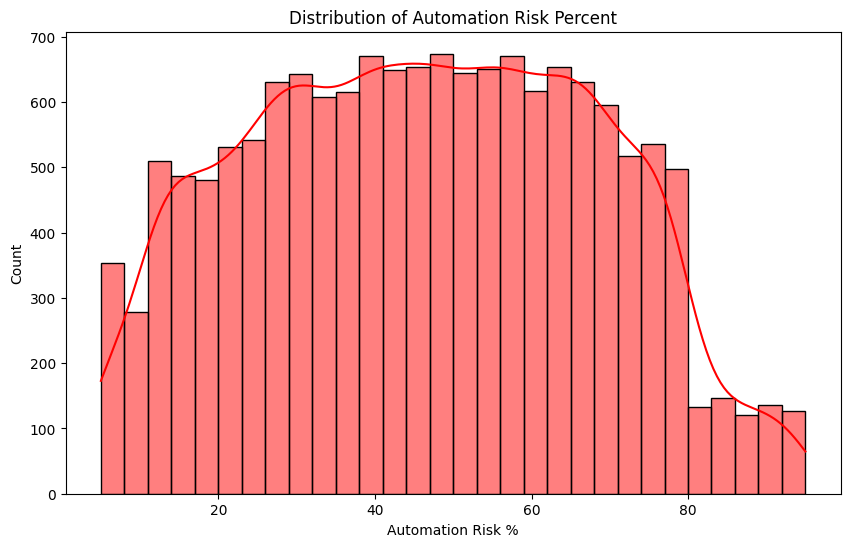

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df["automation_risk_percent"], bins=30, color="red", kde=True)
plt.title("Distribution of Automation Risk Percent")
plt.xlabel("Automation Risk %")
plt.ylabel("Count")
plt.show()

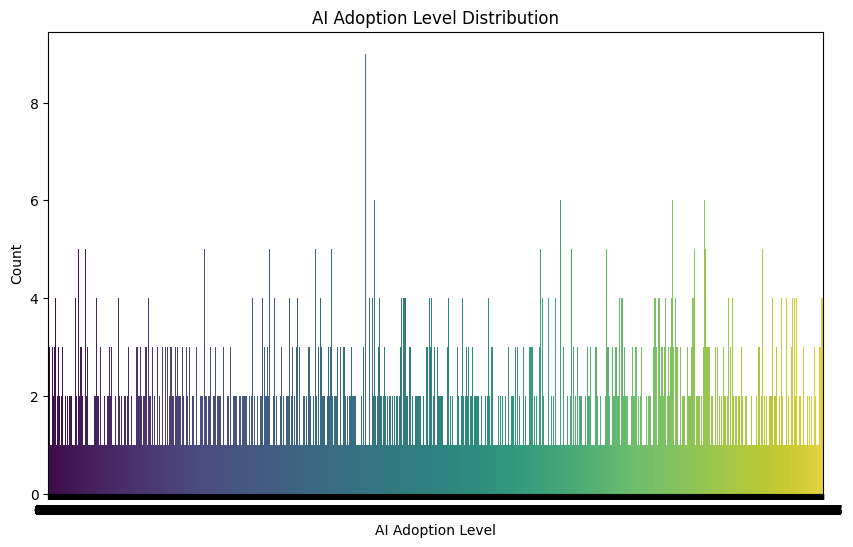

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x="ai_adoption_level", data=df, palette="viridis")

plt.title("AI Adoption Level Distribution")
plt.xlabel("AI Adoption Level")
plt.ylabel("Count")
plt.show()

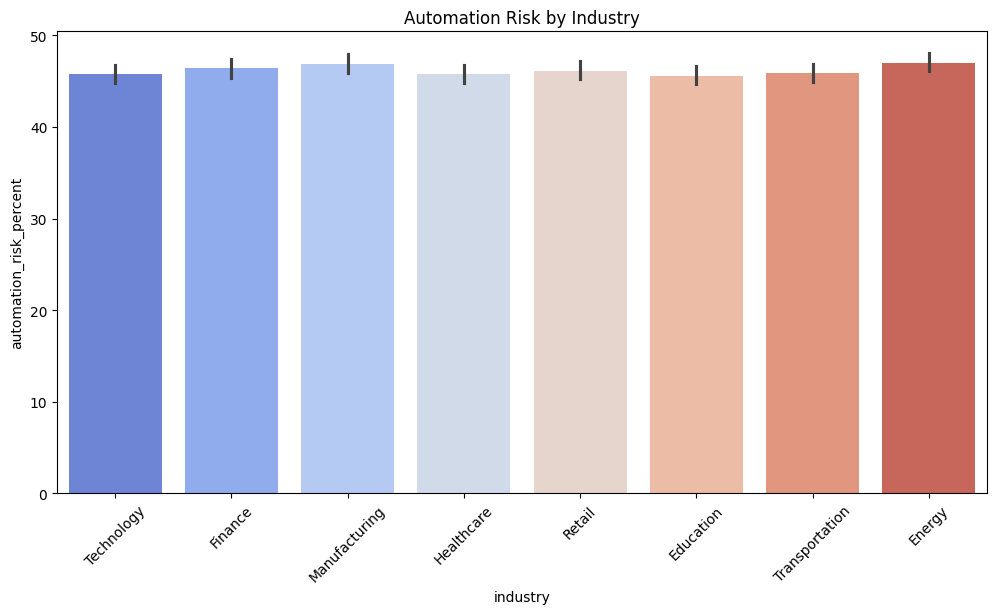

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="industry",
    y="automation_risk_percent",
    data=df,
    palette="coolwarm"
)

plt.xticks(rotation=45)
plt.title("Automation Risk by Industry")
plt.show()

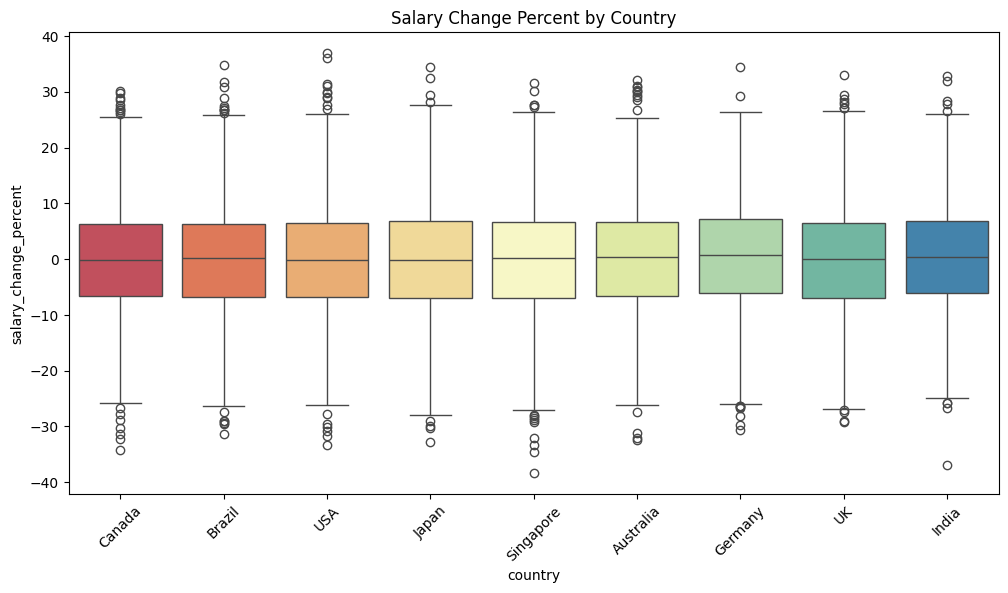

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="country",
    y="salary_change_percent",
    data=df,
    palette="Spectral"
)

plt.xticks(rotation=45)
plt.title("Salary Change Percent by Country")
plt.show()

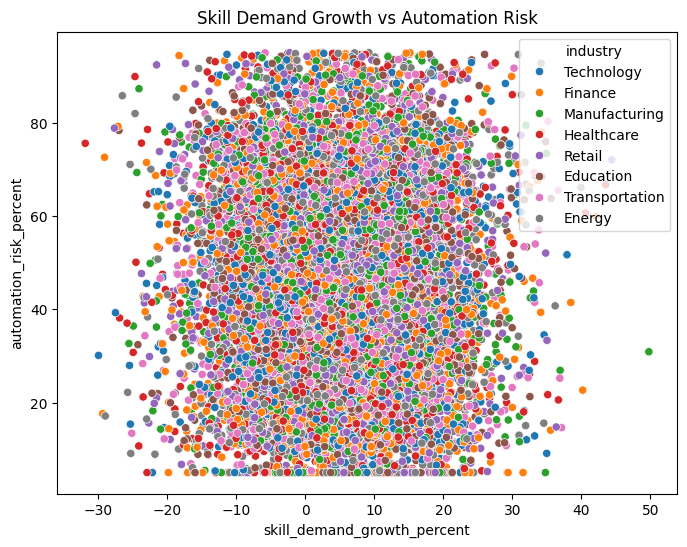

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="skill_demand_growth_percent",
    y="automation_risk_percent",
    hue="industry",
    palette="tab10",
    data=df
)

plt.title("Skill Demand Growth vs Automation Risk")
plt.show()

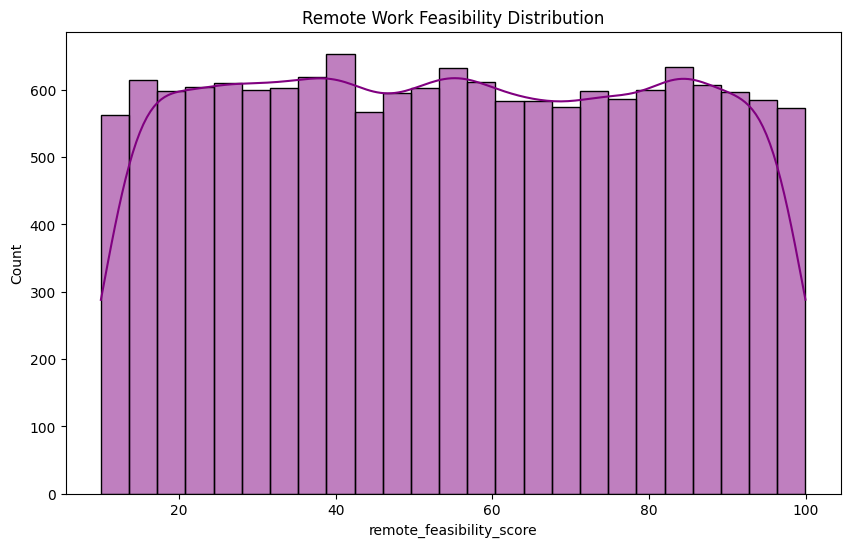

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["remote_feasibility_score"],
    bins=25,
    kde=True,
    color="purple"
)

plt.title("Remote Work Feasibility Distribution")
plt.show()

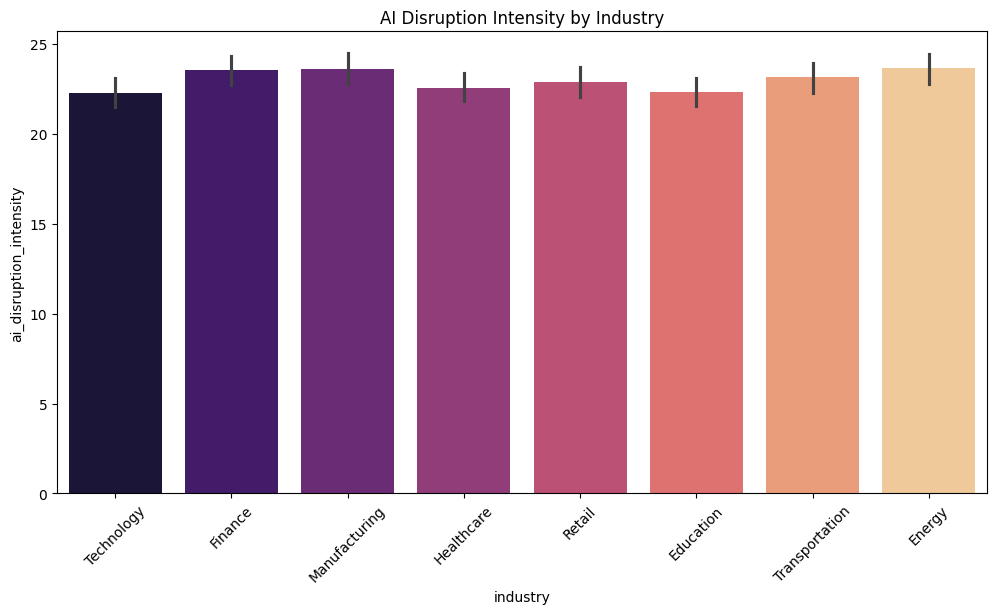

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="industry",
    y="ai_disruption_intensity",
    data=df,
    palette="magma"
)

plt.xticks(rotation=45)
plt.title("AI Disruption Intensity by Industry")
plt.show()

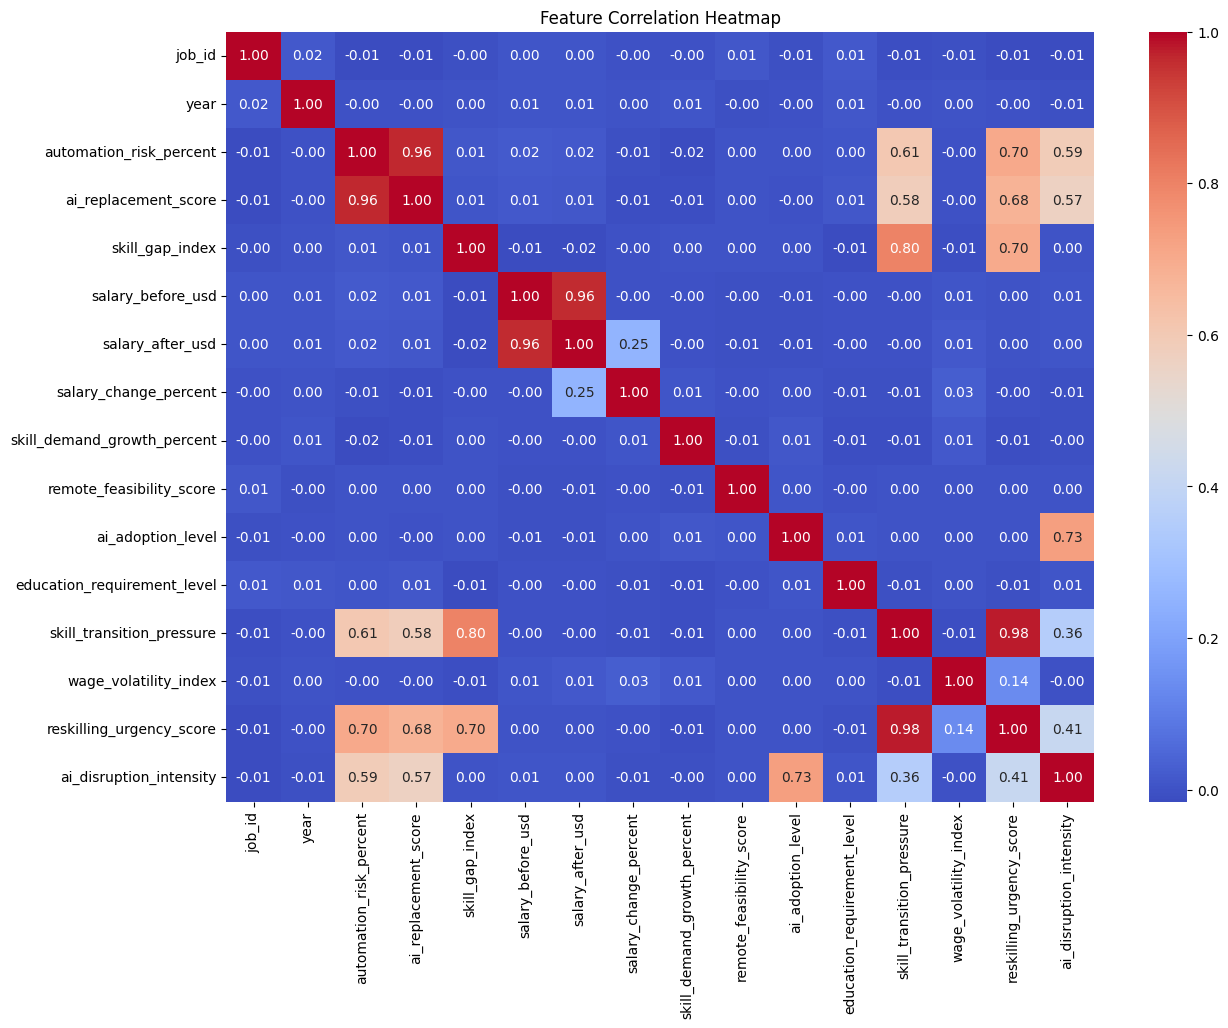

In [20]:
plt.figure(figsize=(14,10))

numeric_cols = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

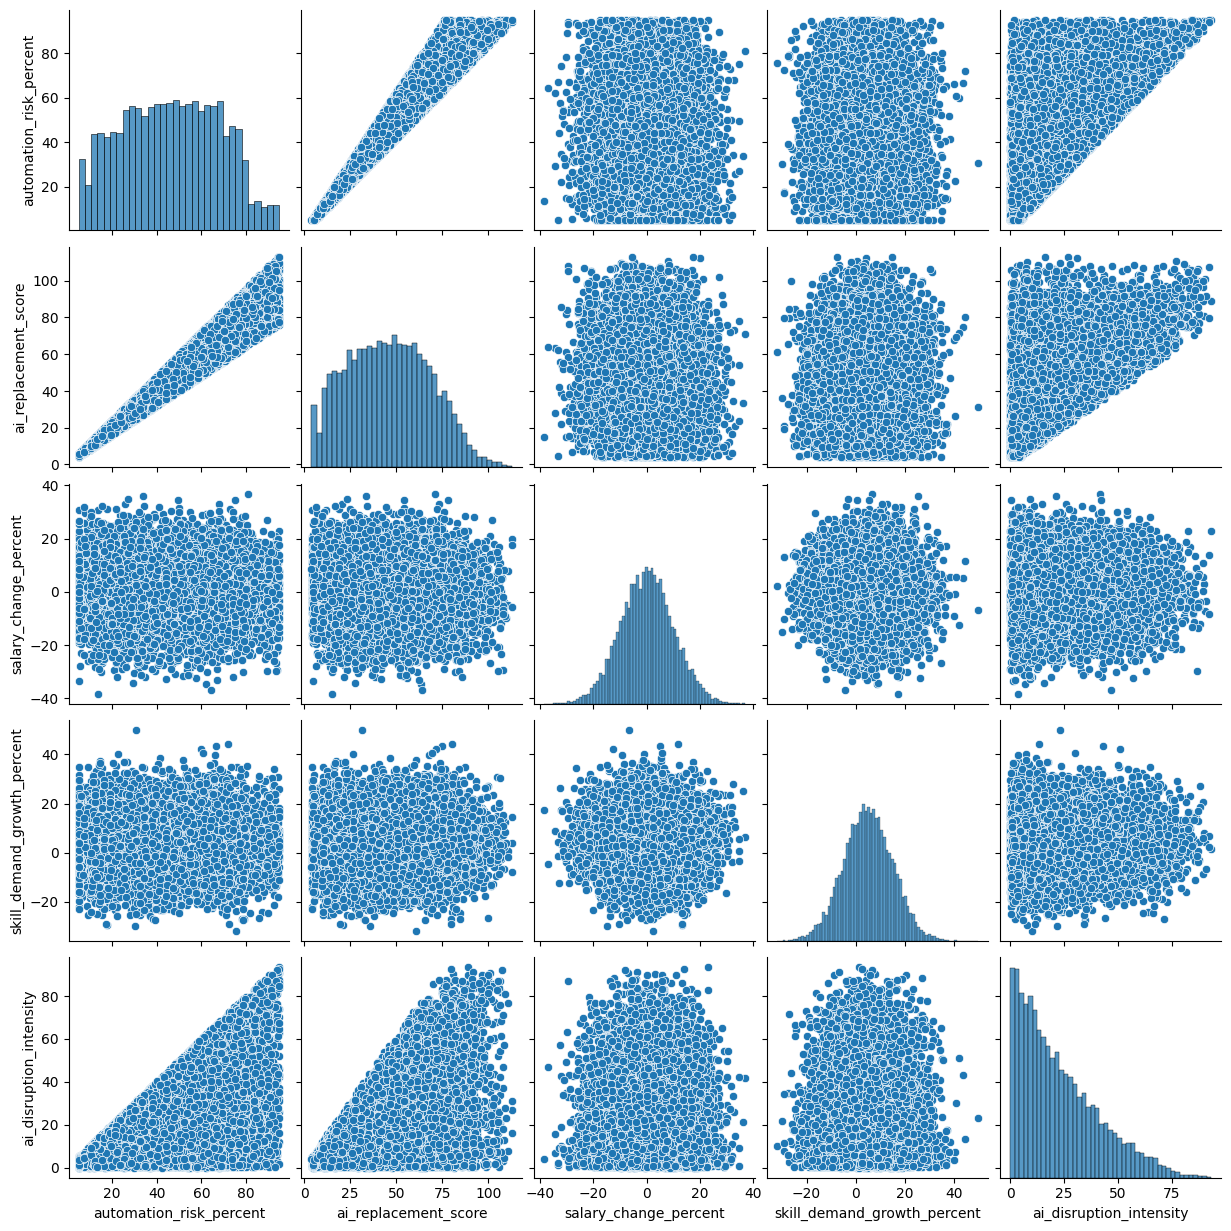

In [21]:
sns.pairplot(
    df[[
        "automation_risk_percent",
        "ai_replacement_score",
        "salary_change_percent",
        "skill_demand_growth_percent",
        "ai_disruption_intensity"
    ]],
    palette="husl"
)

plt.show()

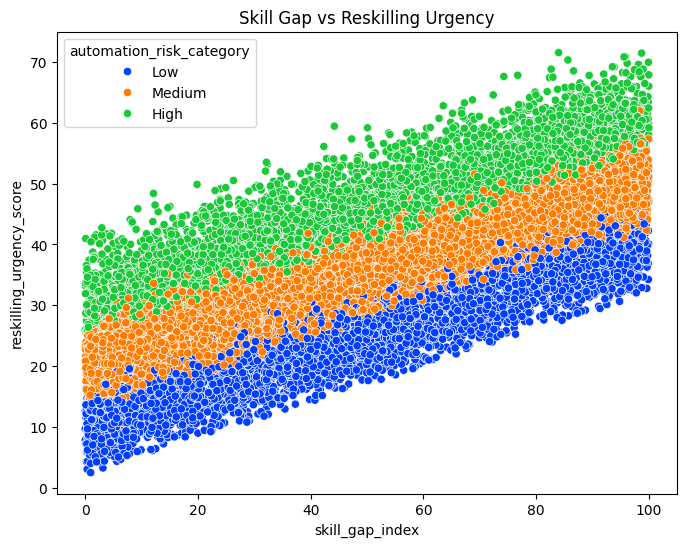

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="skill_gap_index",
    y="reskilling_urgency_score",
    hue="automation_risk_category",
    palette="bright",
    data=df
)

plt.title("Skill Gap vs Reskilling Urgency")
plt.show()

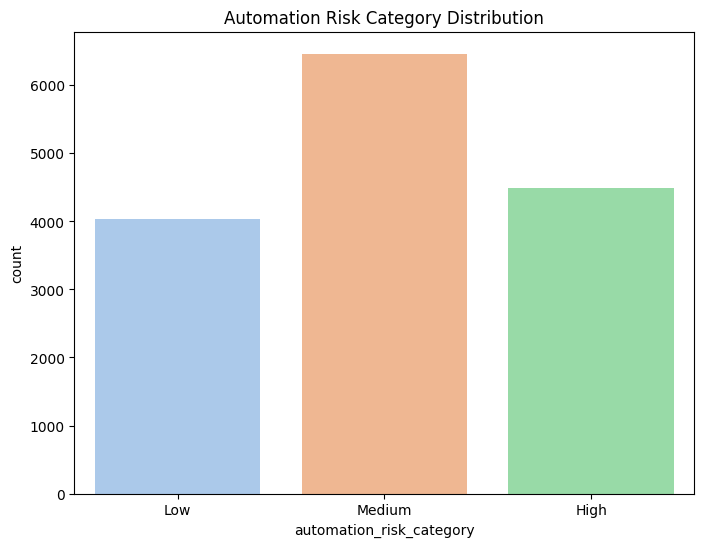

In [23]:
plt.figure(figsize=(8,6))

sns.countplot(
    x="automation_risk_category",
    data=df,
    palette="pastel"
)

plt.title("Automation Risk Category Distribution")
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
imputer = SimpleImputer(strategy="most_frequent")
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [26]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop("automation_risk_category", axis=1)
y = df["automation_risk_category"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Support Vector Machine": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

In [30]:
for name, model in models.items():

    print("\n"+"="*50)
    print("MODEL:", name)
    print("="*50)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", round(acc*100,2),"%")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))


MODEL: Logistic Regression
Accuracy: 93.7 %

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       902
           1       0.98      0.98      0.98       803
           2       0.93      0.92      0.93      1295

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000


MODEL: Decision Tree
Accuracy: 100.0 %

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       902
           1       1.00      1.00      1.00       803
           2       1.00      1.00      1.00      1295

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000


MODEL: Random Forest
Accuracy: 100.0 %

Classification Report
              precision    recall  f1-score 

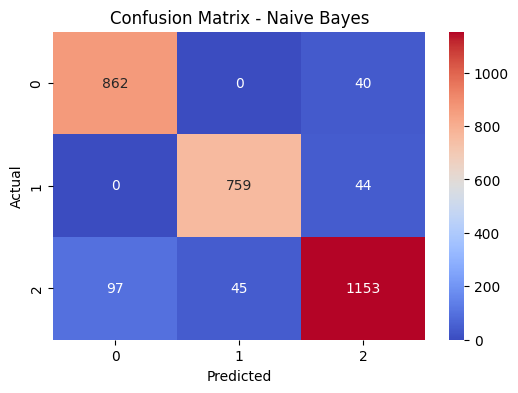

In [31]:
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(cm,
                annot=True,
                cmap="coolwarm",
                fmt="d")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

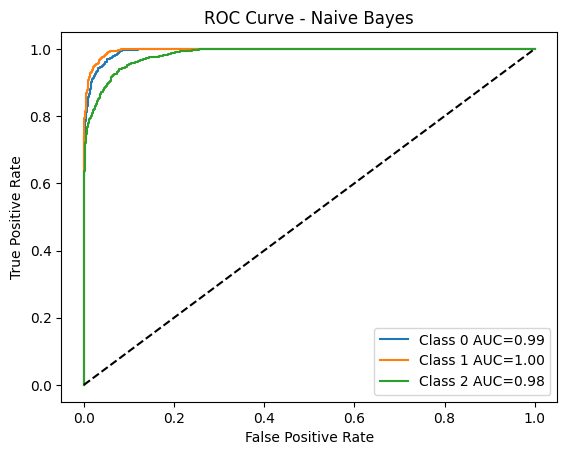

In [32]:
    y_prob = model.predict_proba(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(np.unique(y))):

        fpr[i], tpr[i], _ = roc_curve(y_test==i, y_prob[:,i])

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.2f}")

    plt.plot([0,1],[0,1],'k--')

    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

In [33]:
accuracy_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_results[name] = acc*100

accuracy_df = pd.DataFrame(
    list(accuracy_results.items()),
    columns=["Model","Accuracy %"]
)

print(accuracy_df)

                    Model  Accuracy %
0     Logistic Regression   93.700000
1           Decision Tree  100.000000
2           Random Forest  100.000000
3  Support Vector Machine   97.166667
4                     KNN   88.533333
5             Naive Bayes   92.466667


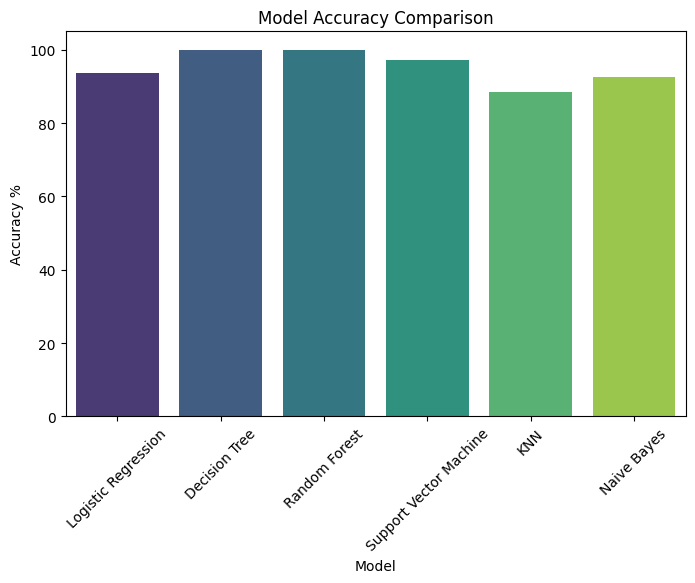

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy %",
    data=accuracy_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

## Thank you..pls upvote!!!!!!!!